# Apophis asteroidearen simulazioa 2029ko hasieran

Hemen LittleEphemeris paketea erabiliz 2029aren hasieran aztertu nahi diren gorputzen posizioa kalkulatuko dugu, eta ondoren Runge-Kutta 4 metodoaren bidez asteroidea nola erakartzen duten eta honen ibilbidea simulatuko da.

Lortutako emaitzak assist programak [ASSIST: An Ephemeris-Quality Test Particle Integrator](https://arxiv.org/abs/2303.16246) artikulokan erabiltzen den demoarekin alderatuko dira, beraz hemendik hartudo da hasierako data.

## Simulazioa

Apophis ateroideak lurraren, ilargiaren eta eguzkiaren erakarpen indarra jasaten du. Erakarpen horren eredu matematiko sinplifikatu bat kontsideratuko dugu. Suposatuko dugu lurra, ilargia eta eguzkia erabat esferikoak direla, masa dentsitate uniformea duena. Eredu matematiko honetan, gainerako astroen erakarpen indarra ez ditugu kontutan hartuko.

Apophisen kokapena $t$ unean zein den zehazteko, $(x(t),y(t),z(t))$ koordenatu kartesiarrak erabiliko ditugu, $(0,0,0)$ jatorria eguzkiaren erdigunea delarik. Bestalde, $t$ uneko Apophisen abiadura $(v_x(t),v_y(t),v_z(t))$ adieraziko dugu.

 Gure eredu matematiko
sinplifikatuan, honako ekuazio diferentzialen sistema betetzen
da:

\begin{aligned}
 \frac{d x}{dt} &= v_x,\\
 \frac{d y}{dt} &= v_y,\\
 \frac{d z}{dt} &= v_z,\\
 \frac{d v_x}{dt} &= \mu_S \frac{x_S(t) - x}{r_S(t)^3} + \mu_E \frac{x_E(t) - x}{r_E(t)^3} + \mu_M \frac{x_M(t) - x}{r_M(t)^3},\\
 \frac{d v_y}{dt} &= \mu_S \frac{y_S(t) - y}{r_S(t)^3} + \mu_E \frac{y_E(t) - y}{r_E(t)^3} + \mu_M \frac{y_M(t) - y}{r_M(t)^3},\\
 \frac{d v_z}{dt} &= \mu_S \frac{z_S(t) - z}{r_S(t)^3} + \mu_E \frac{z_E(t) - z}{r_E(t)^3} + \mu_M \frac{z_M(t) - z}{r_M(t)^3},\\
\end{aligned}

non $\mu_S$, $\mu_E$, $\mu_M$ eguzkiaren, lurraren eta ilargiaren grabitate-konstanteak diren, hurrenez hurren.
Konkretuki, 
\begin{equation*} 
    \mu_S = 1.3271244×10^{11} \, \mbox{Km}^3/\mbox{s}^2, \quad
    \mu_E = 398600.435 \, \mbox{Km}^3/\mbox{s}^2, \quad
    \mu_M = 4902.80 \, \mbox{Km}^3/\mbox{s}^2
\end{equation*}
eta $r_S$, $r_E$, $r_M$ Apophisen distantzia eguzkiarekiko, lurrarekiko eta ilargiarekiko, hurrenez, hurren.
Konkretuki, 
\begin{align*} 
    r_S &= \sqrt{(x_S(t)-x)^2+(y_S(t)-y)^2+(z_S(t)-z)^2}, \\
    r_E &= \sqrt{(x_E(t)-x)^2+(y_E(t)-y)^2+(z_E(t)-z)^2}, \\
    r_M &= \sqrt{(x_M(t)-x)^2+(y_M(t)-y)^2+(z_M(t)-z)^2}
\end{align*}
Distantzia kilometrotan neurtuko dugu eta denbora segundutan.

## Prestaketa
Ezer instalatuta ez dagoela suposatuko da, hala bada gelaxka hauek exekutatu beharko dira.
### Paketearen instalazioa
LittleEphemeris paketea erabiliko dugunez, hau instalatuta izatea beharrezkoa da. Ondorengo gelaxka hau betetzen ez bada bakarrik egikaritu behar da. 

In [1]:
import Pkg
Pkg.add("LittleEphemeris")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.9/Project.toml`
  No Changes to `~/.julia/environments/v1.9/Manifest.toml`


## Datuak deskargatu
Erabiliko diren datuak JPL(Jet Propulsion Laboratory) zentroaren weborritik hartuak dira..
* https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de440.bsp

Fitxategi hau uneko direktorioaren barruan data izeneko direktorio batean egon behar dute.

Daturik ez badago deskargatuta bakarrik exekutatu ondorengo gelaxka.

In [ ]:
generate_files("./data/")

Ondorengo paketa laguntzaileak ere izan behar dira.
* JSON
* CSV
* SPICE
* DataFrames
* FFTW
* Plots
* BenchmarkTools

Ez badaude lehenagotik, deskargatu.

Orain LittleEphemeris paketa erabiltzeko prest legoke dena.

In [ ]:
using LittleEphemeris

In [1]:
using JSON
using CSV
using SPICE
using DataFrames
using FFTW
using Plots
using BenchmarkTools
using LinearAlgebra
using StaticArrays

# Modulu lokalak kargatu
include("dinamika.jl")
using .Dinamika

include("integratzaileak.jl")
using .Integratzaileak

# Karga nukleoak
furnsh("./data/naif0012.tls", "./data/de440.bsp")

## Beharrezko gorputzen posizioaren kalkulua

Hasierako simulazio honetan ilargia, lurra eta eguzkia hartuko dira kontuan, beraz, hauen kokapenak behar ditugu Apophis asteroidearen ibilbidea nola eragiten duten ikusteko.

Horretarako, lurra eguzkia eta ilargiaren Chevycheven polinomioen koefizienteak kalkulatuko ditugu eta fitxategi batean gorde, ondoren hauek ebaluatuko dira eta posizioak kalkulatzeko.

* coeffs.json: polinomioen koefizienteen inguruko informazioa gordetzen du, ez koefiziente berak.
* coeffs.csv: polinomioen koefizienteak gordetzen ditu.

In [3]:
ID_list = [3,5,10,301] #Lurra Jupiter Eguzkia Ilargia

et_0 = 10593.535998938605 *86400     # Assisten simulazioaren hasiera. 2029ko urtarrilaren 1a
et_end =  10958.037242609542 *86400  # Assisten simulazioaren bukaera. 2030eko urtarrilaren 1a

time_interval = (et_0,et_end)
time_interval_list = fill(time_interval, length(ID_list)) #Taula huts bat sortu

create_coeffs_file("./data/coeffs.json", "./data/coeffs.csv", ID_list, time_interval_list)

"./data/coeffs.csv"

Assist-en simulazioan erabilitako emaitzen arteko denbora-tartea:

In [4]:
N_samples = 10000
dt_out = (et_end-et_0)/(N_samples-1)

3149.605705887476

Lurraren, ilargiaren eta eguzkiaren posizioa kalkulatuko da.

In [5]:
# Abrimos el fichero
coeffs_info = open("data/coeffs.json", "r")
# Generamos el vector de diccionarios
coeffs_info_vec = JSON.parse(coeffs_info)

# Intervalo de tiempo del segundo planeta
#time_interval = coeffs_info_vec[2]["timeIntervals"] #Denek bera dute, berdin du
# Numero de intervalos
n_intervals = length(time_interval)-1


n = 10

# Generar vector de instantes de tiempo
tt = Vector{Float64}(undef, n_intervals*n)
for interval_index in 1:n_intervals
    # Instante de tiempo que evaluaremos
    range = (n*(interval_index-1)+1):(n*interval_index)
    tt[range] = rand(time_interval[interval_index]:time_interval[interval_index+1], n)
end

tt = sort(tt)


# Evaluar los coeficientes

bek = zeros(10000)
bek[1] = et_0
ink = (et_end-et_0)/10000
n = length(ID_list)
x = [Vector{Float64}() for _ in 1:n]
y = [Vector{Float64}() for _ in 1:n]
z = [Vector{Float64}() for _ in 1:n]
vx = [Vector{Float64}() for _ in 1:n]
vy = [Vector{Float64}() for _ in 1:n]
vz = [Vector{Float64}() for _ in 1:n]
for i in 2:10000
    bek[i] = bek[i-1] + ink
end
for i in 1:length(ID_list)
    x[i], y[i], z[i], vx[i], vy[i], vz[i] = eval_coeffs_file("data/coeffs.json", "data/coeffs.csv", ID_list[i], bek)
end

#Ilargia kordenatu geozentristetatik, heliozentristetara aldatu
x[4] = x[4] + x[1]
y[4] = y[4] + y[1]
z[4] = z[4] + z[1]
vx[4] = vx[4] + vx[1]
vy[4] = vy[4] + vy[1]
vz[4] = vz[4] + vz[1]


10000-element Vector{Float64}:
 -2.697248217132498
 -2.7076770562919275
 -2.718084392779801
 -2.728469940252295
 -2.738833413893021
 -2.749174530462316
 -2.759493008346303
 -2.7697885676056933
 -2.7800609300243107
 -2.7903098191573292
 -2.800534960379203
 -2.81073608093126
 -2.820912909968955
  ⋮
 -2.2886894150700465
 -2.292685103997305
 -2.2966688464717997
 -2.300640977554903
 -2.3046018340951324
 -2.308551754672699
 -2.3124910795432307
 -2.3164201505806714
 -2.3203393112193926
 -2.324248906395521
 -2.3281492824875123
 -2.3320407872559867

eval_coeffs_file funtzioaren bidez hainbat emaitza lortu dira:

* x: Gorputzaren x koordenatua denbora tarteako une bakoitzean gordetzen duen bektorea
* y: Gorputzaren y koordenatua denbora tarteako une bakoitzean gordetzen duen bektorea
* z: Gorputzaren z koordenatua denbora tarteako une bakoitzean gordetzen duen bektorea
* vx: Gorputzaren abiadura x ardatzean denbora tarteako une bakoitzean gordetzen duen bektorea
* vy: Gorputzaren abiadura y ardatzean denbora tarteako une bakoitzean gordetzen duen bektorea
* vz: Gorputzaren abiazura z ardatzean denbora tarteako une bakoitzean gordetzen duen bektorea

In [6]:
plt = plot(aspect_ratio = :equal)

plot!(plt, x[1], y[1], label="Body $(ID_list[1])")
#plot!(plt, x[2], y[2], label="Body $(ID_list[2])")
plot!(plt, x[4], y[4], label="Body $(ID_list[4])")


xlabel!("x")
ylabel!("y")
title!("Lurra eta ilargiaren ibilbidea")

display(plt)

LoadError: UndefVarError: `x` not defined

### Kontuan izan behar diren gorputzak

LittleEphemeris paketeak eskeintzen dituen funtzioen bidez, aurrez definitutako denbora tartean gorputz bakoitzaren parametroak gordetzen dituen struct batean jaso.

In [6]:
Earth = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 3, time_interval);
Sun = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 10, time_interval);
Moon = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 301, time_interval);
Jupiter = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 5, time_interval);

## Runge-Kutta 4 

Orain kontuan izan beharreko gorputz guztien abiadurak eta posizioak ditugularik denbora tarteko uneetan. Zenbakizko metodoen bidez apophisengan duen eragina simulatuko da.

Funtzio honek apophisen abiadura eta azelerazioak gordetzen dituen bektore bat itzuliko du.

In [ ]:
# f funtzioa orain Dinamika modulutik dator (f_complete)
# Eredua parametroen bidez definituko dugu (mu zerrenda eta posizio funtzioak)


f (generic function with 1 method)

In [7]:
AU2Km = 149597870.7
t0=et_0
u0_arr=[-5.5946538550488512E-01, # AU
     8.5647564757574512E-01, 
     3.0415066217102493E-01,
     -1.3818324735921638E-02, # AU/day
     -6.0088275597939191E-03, 
     -2.5805044631309632E-03] # Apophisen hasierako egoera, jpl bidez eskuratua

#Kordenatu heliozentrikotatik barizentrikotara pasa
eguzkia_pos_barizentrikoa = [0.001232781221250307, -0.0012750764430978325, -0.0005187131180711941]# Assisten sun_initial.xyz
u0_arr[1] = u0_arr[1] + eguzkia_pos_barizentrikoa[1]
u0_arr[2] = u0_arr[2] + eguzkia_pos_barizentrikoa[2]
u0_arr[3] = u0_arr[3] + eguzkia_pos_barizentrikoa[3]

# Aurreko funtzioek Km eta Km/s unitateak erabiltzen dituzte, beraz konbertsia egin behar da
u0_arr[1:3] *= AU2Km
u0_arr[4:6] *= (AU2Km / (24*60*60))

# SVector bihurtu optimizaziorako
u0 = SVector{6}(u0_arr)

# Parametroak definitu: Eguzkia, Lurra, Ilargia
mu_S = 1.3271244e11
mu_E = 398600.435
mu_M = 4902.80

mu_list_simple = [mu_S, mu_E, mu_M]

# Posizio funtzioak (orden berean)
eph_funcs_simple = [
    Sun,
    Earth,
    t -> Moon(t) + Earth(t)
]

p_simple = (mu_list_simple, eph_funcs_simple)

m_out = 4
h = dt_out/m_out

787.401426471869

In [8]:
Sun(t0)[1:3]/149597870.7

3-element Vector{Float64}:
  0.001232781221250308
 -0.0012750764430978327
 -0.0005187131180711944

In [ ]:
# RK4 funtzioa Integratzaileak modulutik inportatu da
# Header: RK4(u0, t0, T, h, p, f, m=1)


RK4 (generic function with 3 methods)

In [9]:
# Dinamika.f_complete erabiltzen dugu (inportatuta dago)
apophis_data = RK4(u0, t0, et_end, h, p_simple, f_complete, m_out);

In [10]:
apophis_data_luzera = length(apophis_data[2])
apophis_x = zeros(apophis_data_luzera)
apophis_y = zeros(apophis_data_luzera)
apophis_z = zeros(apophis_data_luzera)
lurra_x = zeros(apophis_data_luzera)
lurra_y = zeros(apophis_data_luzera)
tt=apophis_data[1]

for i in 1:apophis_data_luzera
    apophis_x[i] = apophis_data[2][i][1] # x posizioa
    apophis_y[i] = apophis_data[2][i][2] # y posizioa
    apophis_z[i] = apophis_data[2][i][3] # z posizioa
    lurra_x[i] = Earth(tt[i])[1]
    lurra_y[i] = Earth(tt[i])[2]
    #lurra_z[i] = Earth(tt[i])[3]
end

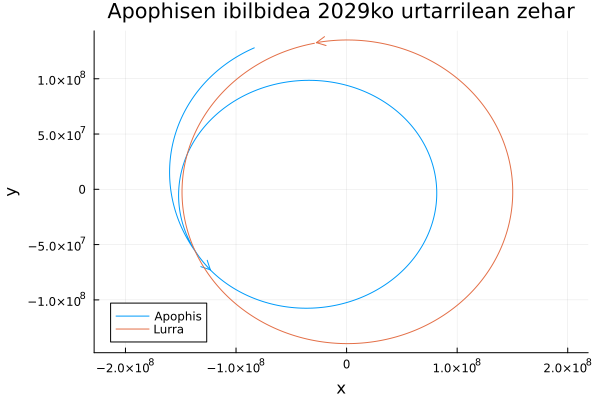

In [11]:
plt = plot(aspect_ratio=:equal)



plot!(plt, apophis_x, apophis_y, label="Apophis", arrow=true)
plot!(plt, lurra_x, lurra_y, label="Lurra", arrow=true)


xlabel!("x")
ylabel!("y")
title!("Apophisen ibilbidea 2029ko urtarrilean zehar")

display(plt)

## Simulazioa Jupiterren eragina kontuan izanda

Orain arteko simulazioan ilargia eguzkia eta lurraren erakarpen indarrak besterik ez ditugu izan kontuan. Simulazioa hobetze aldera, Jupiterren erakarpen indarra ere kontuan izango da, izan ere, eguzki sistema osoan masarik gehien duen planeta baita. 

Horretarako, aurreko f funtzioan oinarrituko da, baina kasu honetan ekuazioa moldatu behar da:


\begin{aligned}
 \frac{d x}{dt} &= v_x,\\
 \frac{d y}{dt} &= v_y,\\
 \frac{d z}{dt} &= v_z,\\
 \frac{d v_x}{dt} &= \mu_S \frac{x_S - x}{r_S^3} + \mu_E \frac{x_E - x}{r_E^3} + \mu_M \frac{x_M - x}{r_M^3} + \mu_J \frac{x_J - x}{r_J^3},\\
 \frac{d v_y}{dt} &= \mu_S \frac{y_S - y}{r_S^3} + \mu_E \frac{y_E - y}{r_E^3} + \mu_M \frac{y_M - y}{r_M^3} + \mu_J \frac{y_J - y}{r_J^3},\\
 \frac{d v_z}{dt} &= \mu_S \frac{z_S - z}{r_S^3} + \mu_E \frac{z_E - z}{r_E^3} + \mu_M \frac{z_M - z}{r_M^3} + \mu_J \frac{z_J - z}{r_J^3},\\
\end{aligned}

non $\mu_S$, $\mu_E$, $\mu_M$ eguzkiaren, lurraren eta ilargiaren grabitate-konstanteak diren, hurrenez hurren.
Konkretuki, 
\begin{equation*} 
    \mu_S = 1.3271244×10^{11} \, \mbox{Km}^3/\mbox{s}^2.
    \mu_E = 398600.435 \, \mbox{Km}^3/\mbox{s}^2.
    \mu_M = 4902.80 \, \mbox{Km}^3/\mbox{s}^2.
    \mu_J = \mu_J = 1.2668653 \times 10^{8} \, \mbox{Km}^3/\mbox{s}^2.
\end{equation*}
eta $r_S$, $r_E$, $r_M$ eta $r_J$ Apophisen distantzia eguzkiarekiko, lurrarekiko, ilargiarekiko eta jupiterrekiko, hurrenez, hurren.
Konkretuki, 
\begin{equation*} 
    r_S = \sqrt{(x_S-x)^2+(y_S-y)^2+(z_S-z)^2}
    r_E = \sqrt{(x_E-x)^2+(y_E-y)^2+(z_E-z)^2}
    r_M = \sqrt{(x_M-x)^2+(y_M-y)^2+(z_M-z)^2}
    r_J = \sqrt{(x_J-x)^2+(y_J-y)^2+(z_J-z)^2}
\end{equation*}

Hortaz, f funtzioa moldatu behar da.

In [ ]:
# Jupiterren eredua definitzeko, parametroen zerrenda luzatu besterik ez dugu behar


f_jupiter (generic function with 1 method)

In [12]:
mu_J = 1.2668653e8

# Parametroak luzatu: Eguzkia, Lurra, Ilargia, Jupiter
mu_list_j = [mu_S, mu_E, mu_M, mu_J]

eph_funcs_j = [
    Sun,
    Earth,
    t -> Moon(t) + Earth(t),
    Jupiter
]

p_j = (mu_list_j, eph_funcs_j)

apophis_data_jupiter = RK4(u0, t0, et_end, h, p_j, f_complete, m_out);

In [13]:
apophis_data_jupiter_luzera = length(apophis_data_jupiter[2])
apophis_x_jupiter = zeros(apophis_data_jupiter_luzera)
apophis_y_jupiter = zeros(apophis_data_jupiter_luzera)
apophis_z_jupiter = zeros(apophis_data_jupiter_luzera)
tt=apophis_data[1]

for i in 1:apophis_data_luzera
    apophis_x_jupiter[i] = apophis_data_jupiter[2][i][1] # x posizioa
    apophis_y_jupiter[i] = apophis_data_jupiter[2][i][2] # y posizioa
    apophis_z_jupiter[i] = apophis_data_jupiter[2][i][3] # y posizioa
end

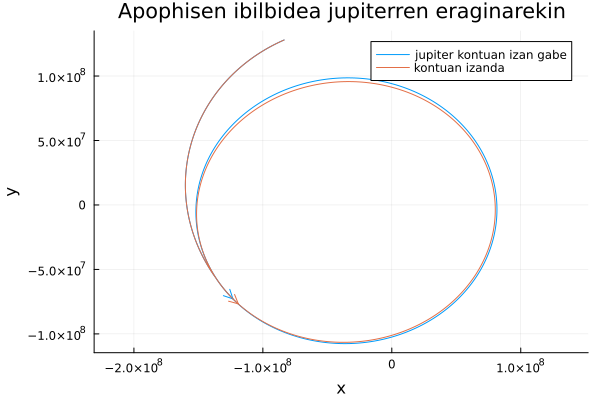

In [14]:
plt_jupiter = plot(aspect_ratio=:equal)



plot!(plt_jupiter, apophis_x, apophis_y, label="jupiter kontuan izan gabe", arrow=true)
plot!(plt_jupiter, apophis_x_jupiter, apophis_y_jupiter, label="kontuan izanda", arrow=true)


xlabel!("x")
ylabel!("y")
title!("Apophisen ibilbidea jupiterren eraginarekin")

display(plt_jupiter)

## Jupiterren eraginaren azterketa eta alderaketa

Begi bistaz, eztirudi aldaketarik dagoenik bi simulaizoen artean, baina sakonago begiratu beahrko da eta assistek eskeintzen dituen emaitzkin alderatu.

In [23]:
# Calculate the total 3D distance error as a single vector
dist_errorea = sqrt.( (apophis_x_jupiter .- apophis_x).^2 .+ 
                      (apophis_y_jupiter .- apophis_y).^2 .+ 
                      (apophis_z_jupiter .- apophis_z).^2 )
# Create the plot
erroreak = plot(denborak, dist_errorea, 
                label="Total 3D Distantzia", 
                linewidth=2,
                color=:black)

# Add the vertical line at your specific timestamp
target_t = 9.240048691856368e8
vline!([target_t], 
       label="Gertueneko pasatzea", 
       linestyle=:dash, 
       color=:red, 
       lw=1.5)

# Formatting
xlabel!("denbora (s)")
ylabel!("Diferentzia osoa (Km)")
title!("Simulazioen alderaketa: 3D Distantzia")

display(erroreak)

### Assisten emaitzekin alderaketa

Artikuloan erabili dutuzten datuekin alderatuko dira aurreko simulazioko emaitzak. Datuak artikuloan erabili dituzten https://github.com/matthewholman/assist/blob/main/jupyter_examples/Apophis.ipynb notebooketik hrtuta daude zuzenean, inolako aldaketarik gabe.

Bertako apophis_pos aldagaiaren balioak atera dira eta "apophis_pos.txt" fitxategira. Hemen aurki daiteke: https://drive.google.com/file/d/1m35aSUQ7kk2HHfDtUPSCcLrbwRhBFsZ5/view?usp=drive_link

In [20]:
function extract_data(filename)
    data = Vector{Vector{Float64}}()
    
    # This regex captures:
    # 1. An optional sign [-+]
    # 2. Digits and an optional decimal \d*\.?\d+
    # 3. An optional exponent ([eE][-+]?\d+)?
    number_regex = r"[-+]?\d*\.?\d+([eE][-+]?\d+)?"

    open(filename, "r") do file
        for line in eachline(file)
            # Find all numbers in the line that match the pattern
            matches = eachmatch(number_regex, line)
            
            # Convert the matches to Float64
            row = [parse(Float64, m.match) for m in matches]
            
            # Only add to our list if the line actually contained numbers
            if !isempty(row)
                push!(data, row)
            end
        end
    end
    return data
end

# To run it:
# assist_apophis_pos = extract_data("your_file.txt")

extract_data (generic function with 1 method)

In [21]:
assist_apophis_pos = extract_data("data/apophis_pos.txt");
length(assist_apophis_pos)

10000

In [22]:
denborak = tt[1:3238]

3238-element Vector{Float64}:
 9.152815103082955e8
 9.152846599140012e8
 9.15287809519707e8
 9.152909591254127e8
 9.152941087311184e8
 9.152972583368242e8
 9.153004079425299e8
 9.153035575482357e8
 9.153067071539414e8
 9.153098567596471e8
 9.153130063653529e8
 9.153161559710586e8
 9.153193055767643e8
 ⋮
 9.254421383150065e8
 9.254452879207122e8
 9.25448437526418e8
 9.254515871321237e8
 9.254547367378294e8
 9.254578863435352e8
 9.254610359492409e8
 9.254641855549467e8
 9.254673351606524e8
 9.254704847663581e8
 9.254736343720639e8
 9.254767839777696e8

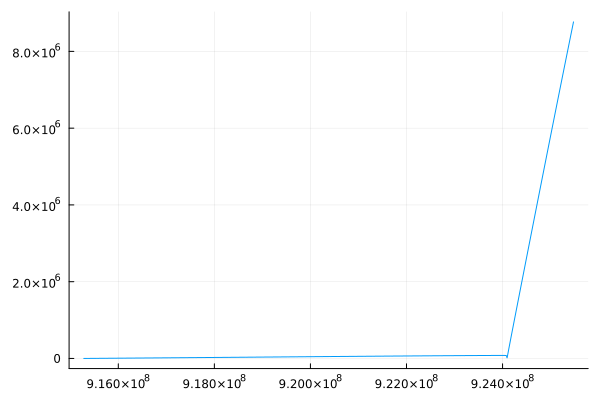

In [24]:
assist_apophis_pos_laburra = assist_apophis_pos[1:length(denborak)]*AU2Km

apophis_pos_jupyter = [u[1:3] for u in apophis_data_jupiter[2][1:length(denborak)]]

diferentziak = assist_apophis_pos_laburra - apophis_pos_jupyter

distantziak = [norm(dif) for dif in diferentziak]

plot(denborak, distantziak, legend=false)

In [25]:
t_end_index = 3238 # 2029-04-30T00:00:00 datari dagokion indizea

assist_apophis_pos_x = zeros(t_end_index)
assist_apophis_pos_y = zeros(t_end_index)
for i in 1:t_end_index
    assist_apophis_pos_x[i] = assist_apophis_pos[i][1] * 149597870.7 # Km-tara
    assist_apophis_pos_y[i] = assist_apophis_pos[i][2] * 149597870.7
end


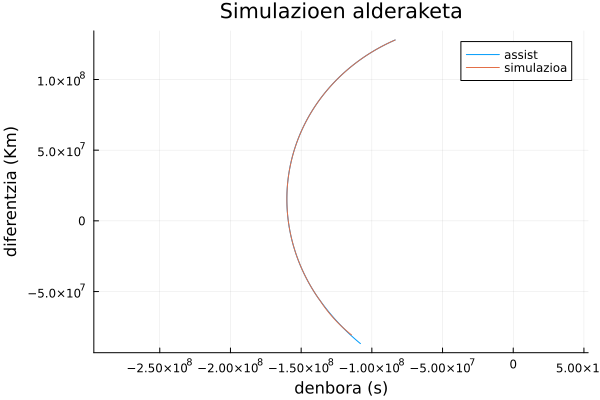

In [26]:
assist_sim = plot(aspect_ratio=:equal)



plot!(assist_sim,assist_apophis_pos_x ,assist_apophis_pos_y, label="assist")
plot!(assist_sim,apophis_x_jupiter[1:t_end_index] ,apophis_y_jupiter[1:t_end_index], label="simulazioa")

xlabel!("denbora (s)")
ylabel!("diferentzia (Km)")
title!("Simulazioen alderaketa")

display(assist_sim)

Hasiera datuak berberak dira, baina hilabetearen bukaerarako ikus daiteke banatu direla.

In [27]:
assist_sim_luzera = length(assist_apophis_pos_x)
sim_luzera = length(apophis_x_jupiter)

relative_error = zeros(assist_sim_luzera)

for i in 1:assist_sim_luzera
    
    ref_val = apophis_x_jupiter[i]
    abs_diff = distantziak[i]
    
    # Calculate relative error (safely)
    if ref_val != 0
        relative_error[i] = abs_diff / abs(ref_val)
    else
        relative_error[i] = abs_diff # Fallback if reference is zero
    end
end

In [28]:
plot(erroreak, 
     title="Absolute Position Error (X-axis)", 
     xlabel="Simulation Step", 
     ylabel="Absolute Difference", 
     label="|assist - jupiter|",
     lw=2,
     yscale=:log10,      # Using log scale to see magnitude differences clearly
     color=:blue)



┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/mHQ0Q/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/mHQ0Q/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/mHQ0Q/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/mHQ0Q/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/mHQ0Q/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/mHQ0Q/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/mHQ0Q/src/ticks.jl:191


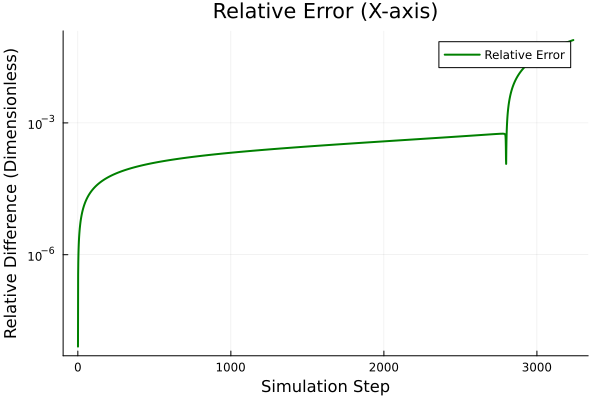

In [29]:
plot(relative_error, 
     title="Relative Error (X-axis)", 
     xlabel="Simulation Step", 
     ylabel="Relative Difference (Dimensionless)", 
     yscale=:log10, 
     lw=2, 
     color=:green,
     label="Relative Error")

### Simulazioa momentu kritikoan

Orain, apophisen apirilaren 13ko hurbilpeneko momentuan egingo da simulazioa, apirila bakarrik izango da kontuan, baina lurraren erakarpenaren indarraren handiagotzearen eraginarekin hobeto ikusiko da natura kaotikoa.

In [240]:
ID_list = [3,5,10,301] #Lurra Jupiter Eguzkia Ilargia

et_0_apirila = utc2et("2029-04-01T12:00:00")
et_end_apirila =  utc2et("2029-04-30T00:00:00")

time_interval_apirila = (et_0_apirila,et_end_apirila)
time_interval_list_apirila = fill(time_interval_apirila, length(ID_list)) #Taula huts bat sortu

create_coeffs_file("./data/coeffs_apirila.json", "./data/coeffs_apirila.csv", ID_list, time_interval_list_apirila)

"./data/coeffs_apirila.csv"

In [242]:
Earth = BodyCoeffs("data/coeffs_apirila.json", "data/coeffs_apirila.csv", 3, time_interval_apirila);
Sun = BodyCoeffs("data/coeffs_apirila.json", "data/coeffs_apirila.csv", 10, time_interval_apirila);
Moon = BodyCoeffs("data/coeffs_apirila.json", "data/coeffs_apirila.csv", 301, time_interval_apirila);
Jupiter = BodyCoeffs("data/coeffs_apirila.json", "data/coeffs_apirila.csv", 5, time_interval_apirila);

In [ ]:
t0=et_0
u0_arr=[-0.99856573, # AU
     -0.22904473, 
     -0.11026611,
     5.72796572e-03, # AU/day
     -1.38806763e-02, 
     -5.01162436e-03] # Apophisen apirlieko egoera, assist erabilita kalkulatua

#Kordenatu heliozentrikotatik barizentrikotara pasa
eguzkia_pos_barizentrikoa = [0.001232781221250307, -0.0012750764430978325, -0.0005187131180711941] 
u0_arr[1] = u0_arr[1] + eguzkia_pos_barizentrikoa[1]
u0_arr[2] = u0_arr[2] + eguzkia_pos_barizentrikoa[2]
u0_arr[3] = u0_arr[3] + eguzkia_pos_barizentrikoa[3]

# Aurreko funtzioek Km eta Km/s unitateak erabiltzen dituzte, beraz konbertsia egin behar da
u0_arr[1:3] *= 149597870.7
u0_arr[4:6] *= (149597870.7 / (24*60*60))

u0 = SVector{6}(u0_arr)

-8.677411261623268

In [ ]:
apophis_data_apirila = RK4(u0, et_0_apirila, et_end_apirila, h, p_j, f_complete, m_out);

([9.230112691856556e8, 9.230121331856556e8, 9.230129971856556e8, 9.230138611856556e8, 9.230147251856556e8, 9.230155891856556e8, 9.230164531856556e8, 9.230173171856556e8, 9.230181811856556e8, 9.230190451856556e8  …  9.254658931856556e8, 9.254667571856556e8, 9.254676211856556e8, 9.254684851856556e8, 9.254693491856556e8, 9.254702131856556e8, 9.254710771856556e8, 9.254719411856556e8, 9.254728051856556e8, 9.254736691856556e8], [[-1.491988855162531e8, -3.445535262392357e7, -1.6573173644339584e7, 9.917725406881857, -24.033791879119843, -8.677411261623268], [-1.4919031458107516e8, -3.4476117354270756e7, -1.6580670703138126e7, 9.922402318812722, -24.032713435035678, -8.676891468398386], [-1.49181739605048e8, -3.449688115253342e7, -1.6588167312720276e7, 9.927079224511841, -24.0316342760405, -8.67637140885938], [-1.4917316058817703e8, -3.451764401809384e7, -1.659566347285593e7, 9.931756123893965, -24.03055440206674, -8.67585108298266], [-1.4916457753046775e8, -3.453840595033425e7, -1.660315918331

In [326]:
apophis_data_apirila_luzera = length(apophis_data_apirila[2])
apophis_x_apirila = zeros(apophis_data_apirila_luzera)
apophis_y_apirila = zeros(apophis_data_apirila_luzera)
apophis_z_apirila = zeros(apophis_data_apirila_luzera)
tt=apophis_data_apirila[1]


lurra_x_apirila = zeros(apophis_data_apirila_luzera)
lurra_y_apirila = zeros(apophis_data_apirila_luzera)

for i in 1:apophis_data_apirila_luzera
    apophis_x_apirila[i] = apophis_data_apirila[2][i][1] # x posizioa
    apophis_y_apirila[i] = apophis_data_apirila[2][i][2] # y posizioa
    apophis_z_apirila[i] = apophis_data_apirila[2][i][3] # y posizioa
    
    lurra_x_apirila[i] = Earth(tt[i])[1]
    lurra_y_apirila[i] = Earth(tt[i])[2]
end

In [327]:
# Apirila bakarrik aztertuko danez lehen
total_points = length(assist_apophis_pos)

t_start_index = 2454 # apirilaren 1ean
t_end_index   = 3236 # apirilaren 30ean

assist_apophis_pos_x = zeros(t_end_index - t_start_index+1)
assist_apophis_pos_y = zeros(t_end_index - t_start_index+1)
for i in t_start_index:t_end_index
    assist_apophis_pos_x[i-t_start_index+1] = assist_apophis_pos[i][1] * 149597870.7 # Km-tara
    assist_apophis_pos_y[i-t_start_index+1] = assist_apophis_pos[i][2] * 149597870.7
end


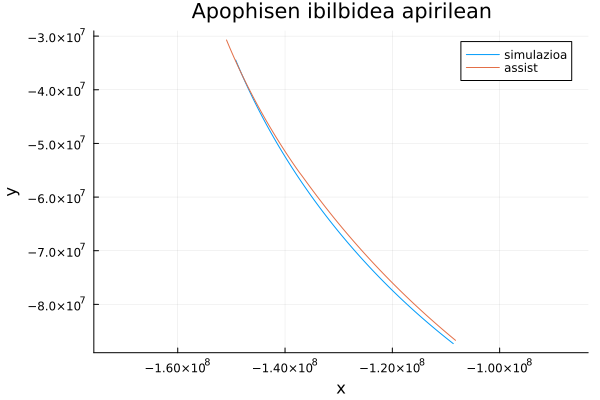

In [328]:
plt_apirila = plot(aspect_ratio=:equal)



plot!(plt_apirila, apophis_x_apirila, apophis_y_apirila, label="simulazioa")
plot!(plt_apirila, assist_apophis_pos_x, assist_apophis_pos_y, label="assist")



xlabel!("x")
ylabel!("y")
title!("Apophisen ibilbidea apirilean")

display(plt_apirila)

In [329]:
assist_sim_luzera = length(assist_apophis_pos_x)
sim_luzera = length(apophis_x_apirila)

# Pre-allocate all 6 vectors
abs_err_x, abs_err_y, abs_err_z = zeros(assist_sim_luzera), zeros(assist_sim_luzera), zeros(assist_sim_luzera)
rel_err_x, rel_err_y, rel_err_z = zeros(assist_sim_luzera), zeros(assist_sim_luzera), zeros(assist_sim_luzera)

for i in 1:assist_sim_luzera
    # 1. Map Index
    idx = clamp(round(Int, i/assist_sim_luzera * sim_luzera), 1, sim_luzera)
    
    # 2. Reference Values
    rx, ry, rz = apophis_x_apirila[idx], apophis_y_apirila[idx], apophis_z_apirila[idx]
    
    # 3. Calculate Absolute Errors
    abs_err_x[i] = abs(assist_apophis_pos_x[i] - rx)
    abs_err_y[i] = abs(assist_apophis_pos_y[i] - ry)
    #abs_err_z[i] = abs(assist_apophis_pos_z[i] - rz)
    
    # 4. Calculate Relative Errors (with safety checks)
    rel_err_x[i] = (rx != 0) ? abs_err_x[i] / abs(rx) : abs_err_x[i]
    rel_err_y[i] = (ry != 0) ? abs_err_y[i] / abs(ry) : abs_err_y[i]
    #rel_err_z[i] = (rz != 0) ? abs_err_z[i] / abs(rz) : abs_err_z[i]
end

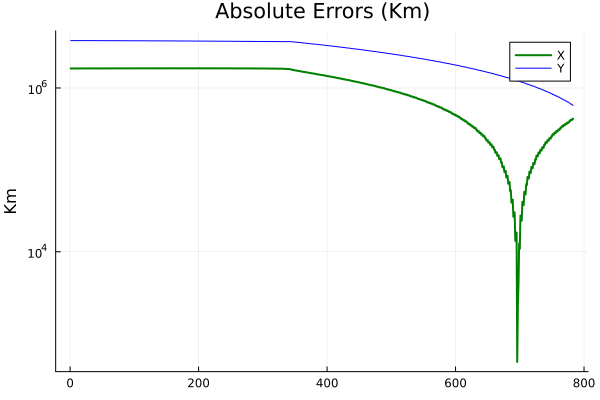

In [330]:
p1 = plot(abs_err_x, title="Absolute Errors (Km)", ylabel="Km", yscale=:log10, lw=2, color=:green, label="X")
plot!(p1, abs_err_y, color=:blue, label="Y")


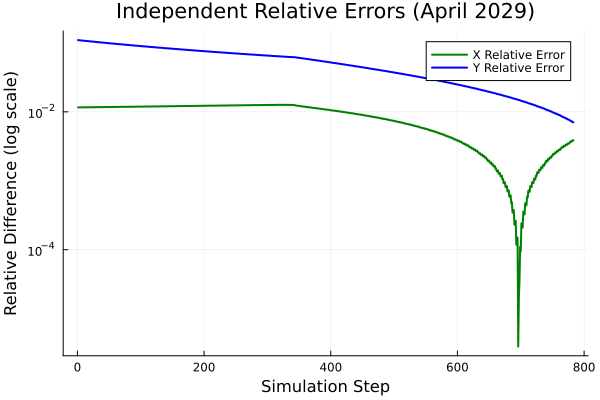

In [346]:
plot(rel_err_x, 
     title="Independent Relative Errors (April 2029)", 
     xlabel="Simulation Step", 
     ylabel="Relative Difference (log scale)", 
     yscale=:log10, 
     lw=2, 
     color=:green,
     label="X Relative Error")

# Add the Y error to the same plot
plot!(rel_err_y, 
      lw=2, 
      color=:blue, 
      label="Y Relative Error")

#### Lurraren ikuspuntutikan hurbilpena

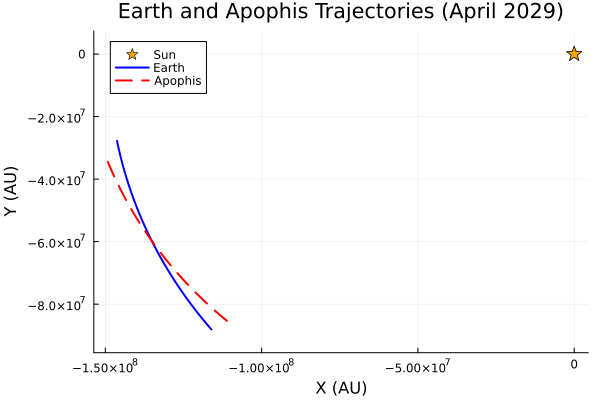

In [331]:
plot(aspect_ratio=:equal, title="Earth and Apophis Trajectories (April 2029)", 
     xlabel="X (AU)", ylabel="Y (AU)", grid=true)

# 1. Plot the Sun at the center
scatter!([0], [0], color=:orange, label="Sun", markersize=8, marker=:star)

# 2. Plot Earth's path
plot!(lurra_x_apirila, lurra_y_apirila, color=:blue, lw=2, label="Earth")

# 3. Plot Apophis's path
plot!(apophis_x_apirila, apophis_y_apirila, color=:red, lw=2, label="Apophis", linestyle=:dash)

## Eguzki sistema osoaren simulazioa

Aurreko modeloa hobetzeko asmoz planeta guztiak kontuan izango dira hemendik aurrera.

In [56]:
ID_list = [1,2,3,4,5,6,7,8,10,301] #Planetak Eguzkia Ilargia


et_0_apirila = utc2et("2029-04-01T12:00:00")
et_end_apirila =  utc2et("2029-04-30T00:00:00")

time_interval = (et_0,et_end)
time_interval_list = fill(time_interval, length(ID_list)) #Taula huts bat sortu

create_coeffs_file("./data/coeffs.json", "./data/coeffs.csv", ID_list, time_interval_list)

"./data/coeffs.csv"

In [51]:
p = [
    2.2031870799 * 10^4 ,
    3.24858592 * 10^5,
    3.986004418 * 10^5,
    4.902800118 * 10^3,
    4.282837 * 10^4 ,
    1.26686534 * 10^8,
    3.7931187* 10^7,
    5.793939 * 10^6 ,
    6.836529 * 10^6,
    1.32712440042 * 10^11
    ]

10-element Vector{Float64}:
  22031.870799
 324858.592
 398600.4418
   4902.800118
  42828.369999999995
      1.26686534e8
      3.7931187e7
      5.793939e6
      6.836529e6
      1.32712440042e11

In [ ]:
# 1. Sortu funtzio zerrenda
# ID_list hemen: [1,2,3,4,5,6,7,8,10,301]
# Dagoeneko BodyCoeffs bidez definitu behar dira edo ID_list erabiliz automatizatu

# Modu errazagoan, ID_list-en ordena mantenduz:
# Kontuz: 301 (Ilargia) + 3 (Lurra) konbinaketa
eph_funcs_full = []
for id in ID_list
    if id == 301
        # Ilargia geozentrikoa da, Lurra gehitu behar diogu
        # Hemen efemeride objektuak berrerabili beharko genituzke eraginkortasunerako, baina
        # BodyCoeffs berriak sortuko ditugu edo aurrekoak erabili.
        # Eraginkorrena: sortu objektuak behin.
        
        # Goian sortutako `create_coeffs_file`-k emandako fitxategiak erabiliz:
        moon_f = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 301, time_interval)
        earth_f = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 3, time_interval)
        push!(eph_funcs_full, t -> moon_f(t) + earth_f(t))
    else
        push!(eph_funcs_full, BodyCoeffs("data/coeffs.json", "data/coeffs.csv", id, time_interval))
    end
end

f_complete (generic function with 1 method)

In [ ]:
# Parametro osoak
# p zerrenda (#VSC-757ff20a zeldan definitua) mu balioak dira
mu_list_full = p 

p_full = (mu_list_full, eph_funcs_full)

apophis_complete = RK4(u0, t0, et_end, h, p_full, f_complete, m_out);

In [97]:
apophis_x = zeros(t_end_index)
apophis_y = zeros(t_end_index)
for i in 1:t_end_index
   apophis_x[i] =  apophis_complete[2][i][1]
   apophis_y[i] =  apophis_complete[2][i][2]
end



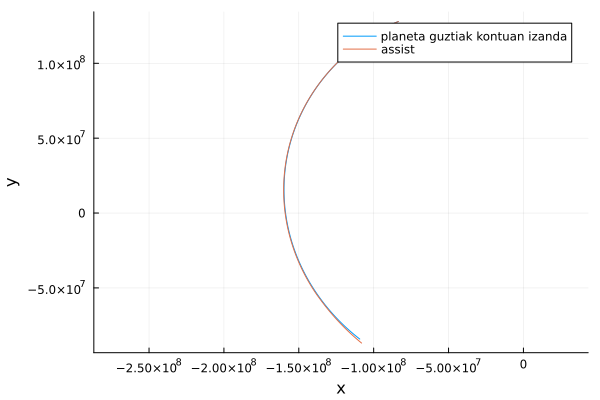

In [99]:
plt_complete = plot(aspect_ratio=:equal)

plot!(plt_complete, apophis_x, apophis_y, label="planeta guztiak kontuan izanda")
plot!(plt_complete,assist_apophis_pos_x ,assist_apophis_pos_y, label="assist")


xlabel!("x")
ylabel!("y")

display(plt_complete)